In [1]:
!pip install -q kaggle
from google.colab import files
files.upload()

ERROR: Operation cancelled by user


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"uffiyannizam1","key":"c91c81d8dc4d0920cf1dfcd9ca2d3f99"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
import os
import shutil

# Create Kaggle folder
os.makedirs('/root/.kaggle', exist_ok=True)

# Move kaggle.json
shutil.move('kaggle.json', '/root/.kaggle/kaggle.json')

# Set permissions
os.chmod('/root/.kaggle/kaggle.json', 600)

print("Kaggle API configured successfully.")

Kaggle API configured successfully.


In [4]:
!kaggle datasets download -d rajumavinmar/finger-print-based-blood-group-dataset

Dataset URL: https://www.kaggle.com/datasets/rajumavinmar/finger-print-based-blood-group-dataset
License(s): unknown
  0% 0.00/58.1M [00:00<?, ?B/s]
100% 58.1M/58.1M [00:00<00:00, 1.70GB/s]


In [5]:
!unzip finger-print-based-blood-group-dataset.zip -d /content/

Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset_blood_group/A-/cluster_1_3319.BMP  
  inflating: /content/dataset_blood_group/A-/cluster_1_3326.BMP  
  inflating: /content/dataset_blood_group/A-/cluster_1_3329.BMP  
  inflating: /content/dataset_blood_group/A-/cluster_1_3350.BMP  
  inflating: /content/dataset_blood_group/A-/cluster_1_3353.BMP  
  inflating: /content/dataset_blood_group/A-/cluster_1_3356.BMP  
  inflating: /content/dataset_blood_group/A-/cluster_1_3372.BMP  
  inflating: /content/dataset_blood_group/A-/cluster_1_3381.BMP  
  inflating: /content/dataset_blood_group/A-/cluster_1_3394.BMP  
  inflating: /content/dataset_blood_group/A-/cluster_1_3404.BMP  
  inflating: /content/dataset_blood_group/A-/cluster_1_3409.BMP  
  inflating: /content/dataset_blood_group/A-/cluster_1_3414.BMP  
  inflating: /content/dataset_blood_group/A-/cluster_1_3416.BMP  
  inflating: /content/dataset_blood_group/A-/cluster_1_3421.BMP  
  inflating: /content/dat

In [6]:
import os
os.listdir('/content')

['.config',
 'finger-print-based-blood-group-dataset.zip',
 'drive',
 'dataset_blood_group',
 'sample_data']

In [7]:
import os
import cv2
from tqdm import tqdm

ORIGINAL_PATH = "/content/dataset_blood_group"
CLAHE_PATH = "/content/dataset_clahe"

os.makedirs(CLAHE_PATH, exist_ok=True)

for class_name in os.listdir(ORIGINAL_PATH):
    class_folder = os.path.join(ORIGINAL_PATH, class_name)
    new_class_folder = os.path.join(CLAHE_PATH, class_name)
    os.makedirs(new_class_folder, exist_ok=True)

    for img_name in tqdm(os.listdir(class_folder)):
        img_path = os.path.join(class_folder, img_name)
        img = cv2.imread(img_path)

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        cl = clahe.apply(gray)
        cl = cv2.cvtColor(cl, cv2.COLOR_GRAY2BGR)

        cv2.imwrite(os.path.join(new_class_folder, img_name), cl)

print("CLAHE preprocessing complete.")

100%|██████████| 1009/1009 [00:00<00:00, 2619.46it/s]

CLAHE preprocessing complete.


In [21]:
# ==========================================
# 1️⃣ IMPORT LIBRARIES
# ==========================================

import tensorflow as tf
import numpy as np
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Concatenate, Input
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.applications import EfficientNetB0




# ==========================================
# 2️⃣ DATASET PATH
# ==========================================

DATASET_PATH = "/content/dataset_clahe"   # <-- CHANGE THIS
CUSTOM_MODEL_PATH = "/content/model.h5"  # <-- CHANGE THIS

IMG_SIZE = 224
BATCH_SIZE = 32


# ==========================================
# 3️⃣ LOAD DATASET
# ==========================================

train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

class_names = train_dataset.class_names
NUM_CLASSES = len(class_names)

print("Classes:", class_names)


# ==========================================
# 4️⃣ PERFORMANCE OPTIMIZATION
# ==========================================

AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.prefetch(buffer_size=AUTOTUNE)


# ==========================================
# 5️⃣ LOAD CUSTOM CNN MODEL (93%)
# ==========================================

# ==========================================
# LOAD CUSTOM CNN MODEL
# ==========================================

custom_model = load_model(CUSTOM_MODEL_PATH)

# Build the model by calling it once

# Create feature extractor
custom_feature_extractor = Model(
    inputs=custom_model.inputs,
    outputs=custom_model.layers[-2].output
)

custom_feature_extractor.trainable = False

print("Custom CNN Loaded Successfully")


# ==========================================
# 6️⃣ EFFICIENTNET MODEL
# ==========================================

efficientnet = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

efficientnet.trainable = False


# ==========================================
# BUILD FUSION MODEL (CORRECT VERSION)
# ==========================================

from tensorflow.keras.layers import Resizing

inputs = Input(shape=(224, 224, 3))

# ---------- Custom CNN branch ----------
resize_for_custom = Resizing(64, 64)(inputs)

custom_features = custom_feature_extractor(resize_for_custom)

# ---------- EfficientNet branch ----------
x = efficientnet(inputs)
x = GlobalAveragePooling2D()(x)

# ---------- Combine both ----------
combined = Concatenate()([custom_features, x])

x = Dense(256, activation="relu")(combined)
x = Dense(128, activation="relu")(x)

outputs = Dense(NUM_CLASSES, activation="softmax")(x)

fusion_model = Model(inputs, outputs)

# ==========================================
# 8️⃣ COMPILE MODEL
# ==========================================

fusion_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

fusion_model.summary()


# ==========================================
# 9️⃣ CALLBACKS
# ==========================================

callbacks = [

    tf.keras.callbacks.EarlyStopping(
        patience=5,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-6
    )

]


# ==========================================
# 🔟 TRAIN MODEL
# ==========================================

history = fusion_model.fit(

    train_dataset,
    validation_data=val_dataset,
    epochs=25,
    callbacks=callbacks

)


# ==========================================
# 1️⃣1️⃣ EVALUATE MODEL
# ==========================================

loss, acc = fusion_model.evaluate(val_dataset)

print("Final Ensemble Accuracy:", acc)


# ==========================================
# 1️⃣2️⃣ SAVE MODEL
# ==========================================

fusion_model.save("blood_group_fusion_model.keras")

Found 6000 files belonging to 8 classes.
Using 4800 files for training.
Found 6000 files belonging to 8 classes.
Using 1200 files for validation.
Classes: ['A+', 'A-', 'AB+', 'AB-', 'B+', 'B-', 'O+', 'O-']


Custom CNN Loaded Successfully


Model: "functional_93"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_25      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resizing (Resizing) │ (None, 64, 64, 3) │          0 │ input_layer_25[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb0      │ (None, 7, 7,      │  4,049,571 │ input_layer_25[0… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_92       │ (None, 1024)      │  3,666,752 │ resizing[0][0]    │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ efficientnetb0[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 2304)      │          0 │ functional_92[0]… │
│ (Concatenate)       │                   │            │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 256)       │    590,080 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 128)       │     32,896 │ dense_16[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 8)         │      1,032 │ dense_17[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 8,340,331 (31.82 MB)

 Trainable params: 624,008 (2.38 MB)

 Non-trainable params: 7,716,323 (29.44 MB)

Epoch 1/25
150/150 ━━━━━━━━━━━━━━━━━━━━ 64s 187ms/step - accuracy: 0.5037 - loss: 1.4519 - val_accuracy: 0.8658 - val_loss: 0.4946 - learning_rate: 1.0000e-04
Epoch 2/25
150/150 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step - accuracy: 0.8490 - loss: 0.4146 - val_accuracy: 0.8850 - val_loss: 0.3763 - learning_rate: 1.0000e-04
Epoch 3/25
150/150 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - accuracy: 0.8723 - loss: 0.3443 - val_accuracy: 0.8783 - val_loss: 0.3501 - learning_rate: 1.0000e-04
Epoch 4/25
150/150 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step - accuracy: 0.8697 - loss: 0.3595 - val_accuracy: 0.8725 - val_loss: 0.3375 - learning_rate: 1.0000e-04
Epoch 5/25
150/150 ━━━━━━━━━━━━━━━━━━━━ 8s 50ms/step - accuracy: 0.8759 - loss: 0.3371 - val_accuracy: 0.8792 - val_loss: 0.3180 - learning_rate: 1.0000e-04
Epoch 6/25
150/150 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - accuracy: 0.8786 - loss: 0.3274 - val_accuracy: 0.8842 - val_loss: 0.3173 - learning_rate: 1.0000e-04
Epoch 7/25
150/150 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - a

In [22]:
# Unfreeze top EfficientNet layers
for layer in efficientnet.layers[-30:]:
    layer.trainable = True

fusion_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_finetune = fusion_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10
)

Epoch 1/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 60s 146ms/step - accuracy: 0.8612 - loss: 0.4037 - val_accuracy: 0.9292 - val_loss: 0.3149
Epoch 2/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 9s 59ms/step - accuracy: 0.8714 - loss: 0.3756 - val_accuracy: 0.9333 - val_loss: 0.3788
Epoch 3/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 9s 58ms/step - accuracy: 0.8784 - loss: 0.3444 - val_accuracy: 0.9350 - val_loss: 0.3761
Epoch 4/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 9s 58ms/step - accuracy: 0.8953 - loss: 0.3064 - val_accuracy: 0.9375 - val_loss: 0.3579
Epoch 5/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 9s 59ms/step - accuracy: 0.8876 - loss: 0.2914 - val_accuracy: 0.9350 - val_loss: 0.3414
Epoch 6/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 8s 55ms/step - accuracy: 0.8941 - loss: 0.2967 - val_accuracy: 0.9333 - val_loss: 0.3283
Epoch 7/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 8s 57ms/step - accuracy: 0.8888 - loss: 0.2985 - val_accuracy: 0.9308 - val_loss: 0.3192
Epoch 8/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 10s 58ms/step - accuracy: 0.8843 - loss: 0.3036 - val_a

In [23]:
import numpy as np

def tta_predict(model, dataset, n_aug=5):

    preds = []

    for i in range(n_aug):
        print(f"TTA round {i+1}")
        p = model.predict(dataset)
        preds.append(p)

    preds = np.mean(preds, axis=0)

    return np.argmax(preds, axis=1)

tta_predictions = tta_predict(fusion_model, val_dataset)

TTA round 1
38/38 ━━━━━━━━━━━━━━━━━━━━ 16s 257ms/step
TTA round 2
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step
TTA round 3
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step
TTA round 4
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step
TTA round 5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step


In [25]:
import numpy as np
from sklearn.metrics import accuracy_score

y_true = []
y_pred = []

for images, labels in val_dataset:

    preds = fusion_model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

accuracy = accuracy_score(y_true, y_pred)

print("Correct Validation Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━

In [26]:
fusion_model.save("blood_group_fingerprint_model.keras")

print("Model saved successfully!")

Model saved successfully!


In [30]:
from google.colab import files
uploaded = files.upload()

Saving cluster_0_1001 (5).BMP to cluster_0_1001 (5).BMP


1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
Predicted Blood Group: A+
Confidence: 98.54 %


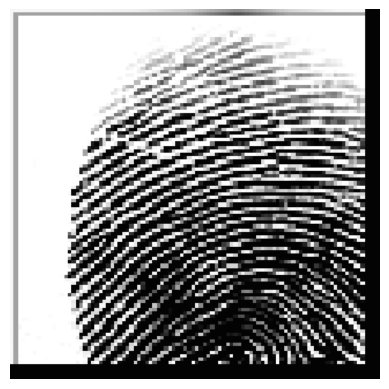

In [31]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# Load model
model = tf.keras.models.load_model("blood_group_fingerprint_model.keras")

class_names = ['A+', 'A-', 'AB+', 'AB-', 'B+', 'B-', 'O+', 'O-']

img_path = list(uploaded.keys())[0]

# Load image
img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)

# Expand dimension
img_array = np.expand_dims(img_array, axis=0)

# ⚠️ DO NOT divide by 255
# img_array = img_array / 255.0   <-- REMOVE THIS

# Predict
pred = model.predict(img_array)

predicted_class = np.argmax(pred)
confidence = pred[0][predicted_class] * 100

plt.imshow(img)
plt.axis("off")

print("Predicted Blood Group:", class_names[predicted_class])
print("Confidence:", round(confidence,2), "%")